# 04 — Avaliação e interpretação

**Dimensão 6 da rubrica — 20 pontos.**

## Navegação
- [1. Métricas no conjunto de teste](#aval-metricas)
- [2. Matriz de confusão](#aval-matriz)
- [3. Importância das variáveis](#aval-importancia)
- [4. Implicações práticas](#aval-implicacoes)
- [5. Limitações e próximos passos](#aval-limitacoes)

A avaliação descreve resultados e limitações sem presumir aplicação operacional.

In [26]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib 

RANDOM_STATE = 42

RAW = Path("..") / "data" / "raw" / "dataset.csv"          
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            

pd.set_option("display.max_columns", None)

# Importando os dados e o modelo da pasta processed
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze() # squeeze transforma DataFrame em Series
rf_model = joblib.load(PROCESSED / "modelo_rf_vencedor.pkl")

print("Modelo e dados importados com sucesso para o Notebook 04!")

Modelo e dados importados com sucesso para o Notebook 04!


<a id="aval-metricas"></a>
## 1. Métricas no conjunto de teste

O código anterior carrega a partição de teste e o pipeline salvos durante a modelagem. A célula seguinte calcula previsões, relatório de classificação e ROC-AUC do Random Forest. A acurácia é reportada, mas não é interpretada isoladamente devido ao desbalanceamento do alvo.

In [27]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay,
)

# Fazendo as previsões na base de teste
y_pred_final = rf_model.predict(X_test)
y_proba_final = rf_model.predict_proba(X_test)[:, 1]

# Exibindo o Relatório de Classificação
print("--- RELATÓRIO DE CLASSIFICAÇÃO (DADOS INÉDITOS DE TESTE) ---")
print(classification_report(y_test, y_pred_final))

# Exibindo o ROC-AUC Final
roc_auc_final = roc_auc_score(y_test, y_proba_final)
print(f"\nROC-AUC Score Final: {roc_auc_final:.4f}")

--- RELATÓRIO DE CLASSIFICAÇÃO (DADOS INÉDITOS DE TESTE) ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10753
           1       0.16      0.30      0.21       185

    accuracy                           0.96     10938
   macro avg       0.57      0.64      0.59     10938
weighted avg       0.97      0.96      0.97     10938


ROC-AUC Score Final: 0.6681


### 1.1 Interpretação das métricas

A saída contém 10.938 registros de teste, dos quais 185 pertencem à classe 1. O Random Forest apresenta acurácia de 0,96 e ROC-AUC de 0,6681. Para a classe 1, a precisão é 0,16, o recall é 0,30 e o F1-score é 0,21, conforme o arredondamento do relatório.

O recall mede a proporção de registros da classe 1 identificados; a precisão mede a proporção de previsões classe 1 que realmente pertencem a essa classe; o F1-score resume precisão e recall. Os custos financeiros dos falsos positivos e falsos negativos não foram quantificados. A ROC-AUC avalia a ordenação em diferentes limiares, mas não determina sozinha um limiar de decisão adequado.

<a id="aval-matriz"></a>
## 2. Matriz de confusão

A matriz apresenta contagens de verdadeiros negativos, falsos positivos, falsos negativos e verdadeiros positivos no conjunto de teste. Interpretá-las como aprovações ou recusas dependeria de uma política de decisão não avaliada neste trabalho.

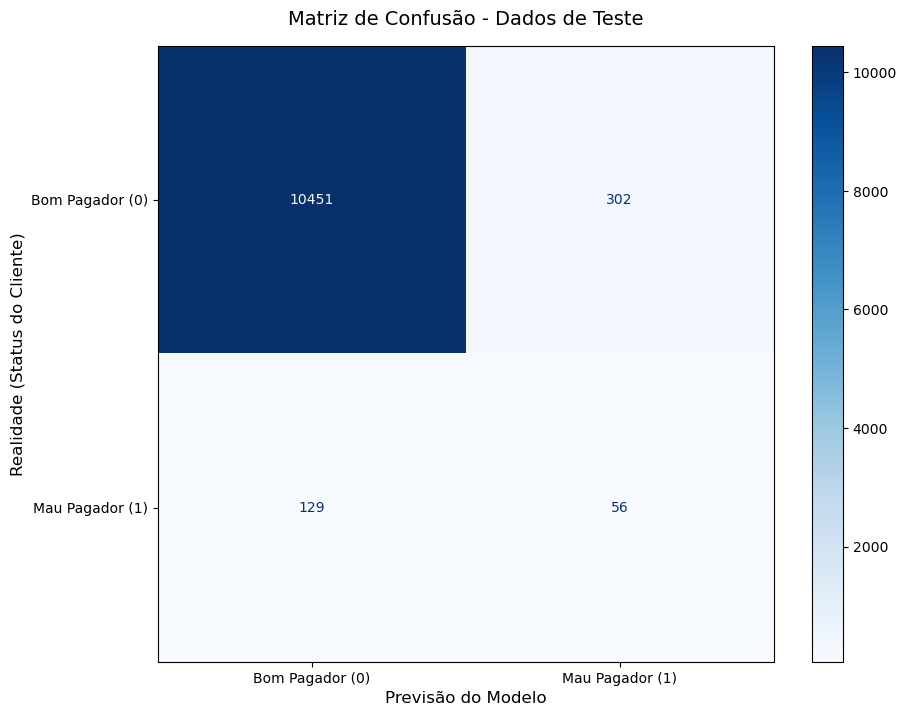

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Criando a figura para melhor visualização
fig, ax = plt.subplots(figsize=(10, 8))

# Gerando e plotando a Matriz de Confusão
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, 
    X_test, 
    y_test, 
    display_labels=['Bom Pagador (0)', 'Mau Pagador (1)'],
    cmap=plt.cm.Blues,
    ax=ax,
    values_format='d'
)

# Alterando os rótulos dos eixos para português
ax.set_ylabel('Realidade (Status do Cliente)', fontsize=12)
ax.set_xlabel('Previsão do Modelo', fontsize=12)

plt.title('Matriz de Confusão - Dados de Teste', pad=15, fontsize=14)
plt.grid(False) # Remove as linhas de grade
plt.show()

**Leitura dos resultados:** A matriz apresenta 10.451 verdadeiros negativos, 302 falsos positivos, 129 falsos negativos e 56 verdadeiros positivos. Com o limiar padrão de predict(), são identificados 56 dos 185 registros da classe 1, correspondendo a recall de aproximadamente 30,27%. As contagens não quantificam impactos financeiros nem o resultado de uma política real de concessão.

<a id="aval-importancia"></a>
## 3. Importância das variáveis

O código extrai as importâncias globais do Random Forest e apresenta as dez variáveis com maiores valores. A importância descreve a participação das variáveis nas divisões das árvores; não representa causalidade, não valida uma regra de negócio e não explica individualmente cada previsão.

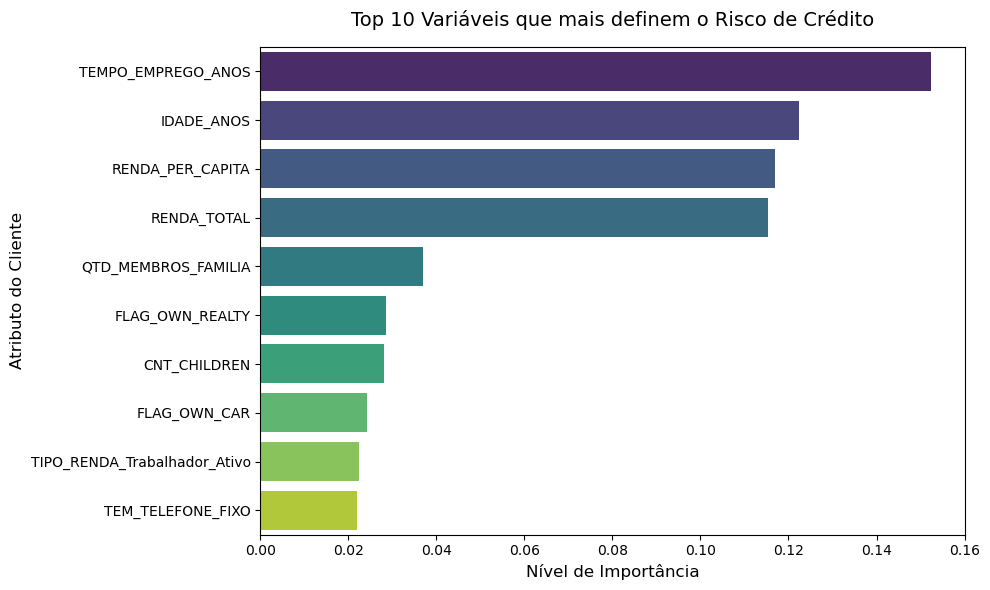

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraindo o modelo final do Pipeline para acessar feature_importances_
modelo_rf = rf_model.named_steps['model'] if hasattr(rf_model, 'named_steps') else rf_model

importancias = modelo_rf.feature_importances_
features = X_test.columns

# Criando um DataFrame para organizar os dados
df_importancias = pd.DataFrame({
    'Variável': features,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# Selecionando as Top 10 variáveis para o gráfico não ficar poluído
top_10_importancias = df_importancias.head(10)

# Criando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importância', 
    y='Variável', 
    data=top_10_importancias, 
    palette='viridis',
    hue='Variável',
    legend=False
)

# Customizando o layout
plt.title('Top 10 Variáveis que mais definem o Risco de Crédito', pad=15, fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Atributo do Cliente', fontsize=12)
plt.tight_layout()
plt.show()

**Leitura do gráfico:** Entre as variáveis exibidas com maior importância relativa estão idade (IDADE_ANOS), tempo de emprego (TEMPO_EMPREGO_ANOS), renda total e renda per capita. Também aparecem variáveis relacionadas ao tamanho familiar e à posse de bens. Essas associações descrevem o modelo ajustado e podem ser influenciadas por correlações entre features; não permitem concluir que uma característica cause aumento ou redução da inadimplência. Explicações individuais exigiriam métodos adicionais e validação específica.

<a id="aval-implicacoes"></a>
## 4. Implicações práticas

Os resultados podem orientar análises futuras, mas não são suficientes para recomendar o uso do modelo em uma política de concessão de crédito. A avaliação de limiares deve considerar dados de validação e custos de falsos positivos e falsos negativos definidos com as áreas responsáveis; essa análise de custo não foi realizada.

Antes de qualquer uso operacional, seriam necessárias validações temporais, análise de vieses, calibração, definição de governança e monitoramento. As métricas atuais não justificam aprovação automática nem campanhas automatizadas.

<a id="aval-limitacoes"></a>
## 5. Limitações e próximos passos

O alvo é retrospectivo: um cliente recebe classe 1 se apresentou atraso grave em qualquer momento do histórico observado, cujo período varia entre clientes. Clientes observados por mais tempo tiveram maior oportunidade de registrar o evento; o rótulo não corresponde a um horizonte futuro fixo.

A classe positiva representa aproximadamente 1,69% da população de modelagem, limitando a quantidade de exemplos disponíveis para aprender padrões raros. As features concentram-se no cadastro e não incluem uma janela recente padronizada de comportamento de crédito. Como próximos passos, podem ser avaliados um alvo temporal explícito, dados comportamentais recentes, limiares orientados a custos, validação fora do tempo e monitoramento de desempenho e vieses.